In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Physical constants
hbar = 1.054571817e-34   # J·s
m_e = 9.1093837e-31     # electron mass, kg
eV = 1.602176634e-19    # joules per electron-volt

print("Physics environment ready.")

Physics environment ready.


In [3]:
# Box parameters
L = 1e-9          # box width: 1 nanometer
N = 500           # number of grid points

x = np.linspace(0, L, N)
dx = x[1] - x[0]

# Interior points only; wavefunction is zero at the walls
x_interior = x[1:-1]
M = len(x_interior)

# Second-derivative finite-difference matrix
main_diag = -2.0 * np.ones(M)
off_diag = np.ones(M - 1)

D2 = (
    np.diag(main_diag)
    + np.diag(off_diag, 1)
    + np.diag(off_diag, -1)
) / dx**2

# Hamiltonian for an electron in an infinite square well
H = -(hbar**2 / (2 * m_e)) * D2

print("Hamiltonian size:", H.shape)
print("Grid spacing:", dx, "m")

Hamiltonian size: (498, 498)
Grid spacing: 2.004008016032064e-12 m


In [4]:
# Solve the Hamiltonian eigenvalue problem
energies, wavefunctions = np.linalg.eigh(H)

# Convert energies from joules to electron-volts
energies_eV = energies / eV

# Display the first 5 energy levels
for n in range(5):
    print(f"n = {n+1}: E = {energies_eV[n]:.4f} eV")

n = 1: E = 0.3760 eV
n = 2: E = 1.5041 eV
n = 3: E = 3.3842 eV
n = 4: E = 6.0162 eV
n = 5: E = 9.4000 eV


In [5]:
# Plot the first 3 wavefunctions

plt.figure(figsize=(10, 6))

for n in range(3):
    psi = wavefunctions[:, n]

    # Normalize the wavefunction
    norm = np.sqrt(np.trapz(np.abs(psi)**2, x_interior))
    psi = psi / norm

    plt.plot(
        x_interior * 1e9,
        psi,
        label=f"n={n+1}, E={energies_eV[n]:.3f} eV"
    )

plt.xlabel("Position x (nm)")
plt.ylabel("Wavefunction ψ(x)")
plt.title("Infinite Square Well: First Three Quantum States")
plt.legend()
plt.grid(True)
plt.show()

AttributeError: module 'numpy' has no attribute 'trapz'

<Figure size 1000x600 with 0 Axes>

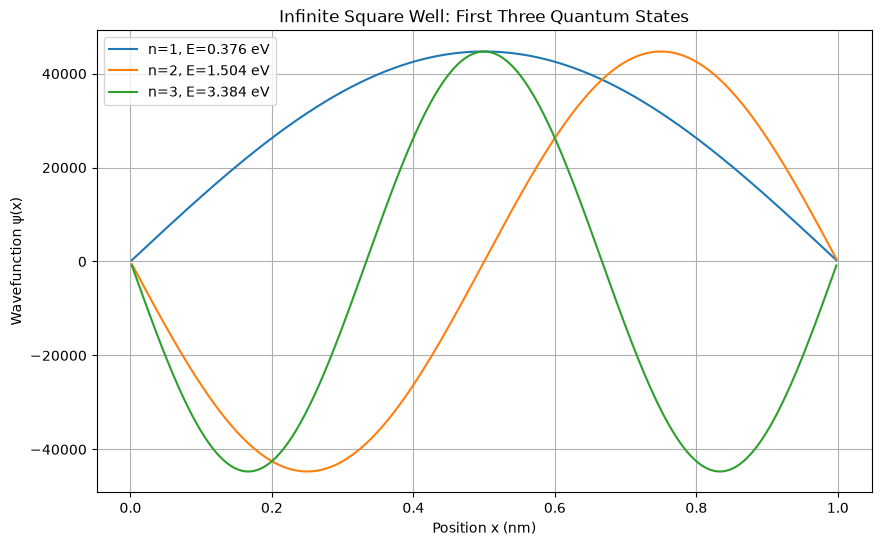

In [6]:
plt.figure(figsize=(10, 6))

for n in range(3):
    psi = wavefunctions[:, n]

    # Normalize so integral |psi|^2 dx = 1
    norm = np.sqrt(
        np.trapezoid(np.abs(psi)**2, x_interior)
    )
    psi = psi / norm

    plt.plot(
        x_interior * 1e9,
        psi,
        label=f"n={n+1}, E={energies_eV[n]:.3f} eV"
    )

plt.xlabel("Position x (nm)")
plt.ylabel("Wavefunction ψ(x)")
plt.title("Infinite Square Well: First Three Quantum States")
plt.legend()
plt.grid(True)
plt.show()

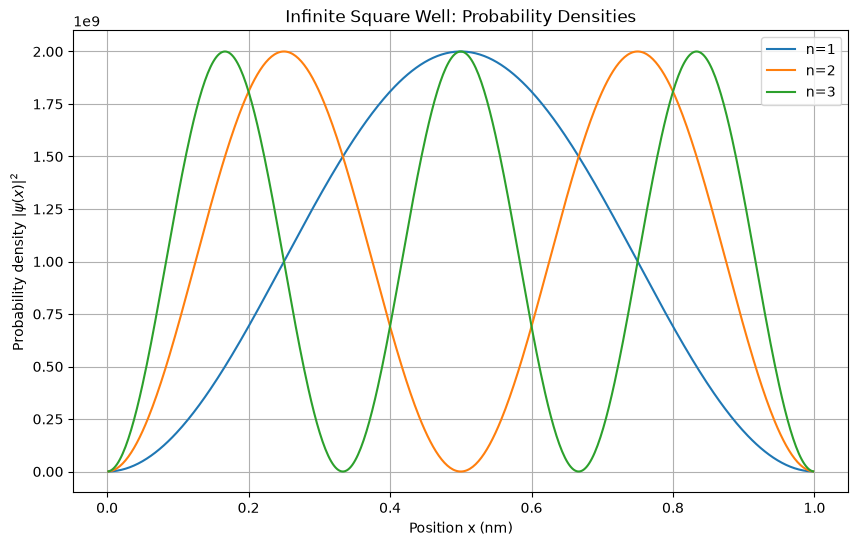

In [7]:
plt.figure(figsize=(10, 6))

for n in range(3):
    psi = wavefunctions[:, n]

    norm = np.sqrt(
        np.trapezoid(np.abs(psi)**2, x_interior)
    )
    psi = psi / norm

    probability = np.abs(psi)**2

    plt.plot(
        x_interior * 1e9,
        probability,
        label=f"n={n+1}"
    )

plt.xlabel("Position x (nm)")
plt.ylabel(r"Probability density $|\psi(x)|^2$")
plt.title("Infinite Square Well: Probability Densities")
plt.legend()
plt.grid(True)
plt.show()